In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

In [3]:
# 1. Load Data
df = pd.read_csv('../data/raw/historical_data.csv', index_col='Date', parse_dates=True)

# 2. Calculate Daily Returns
daily_returns = df.pct_change().dropna()

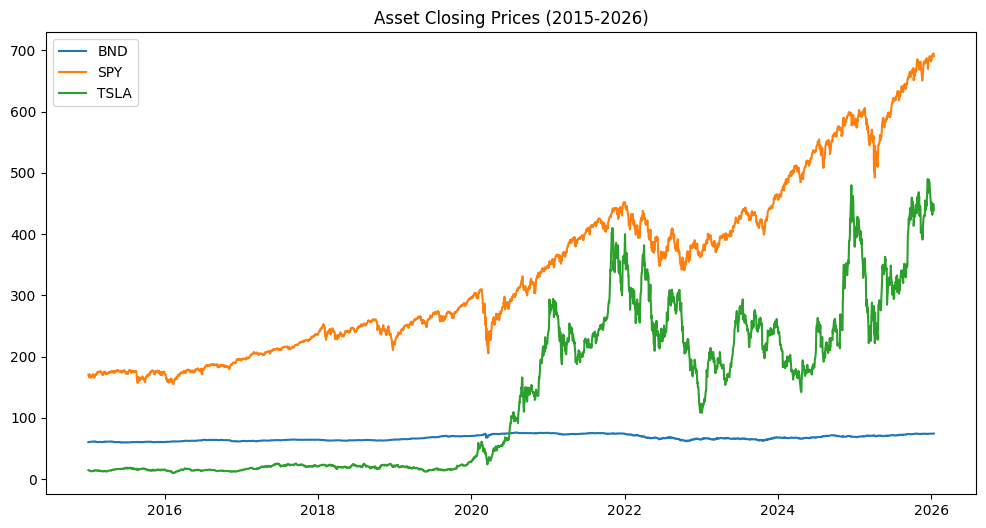

In [4]:
# 3. Visualize Closing Prices
plt.figure(figsize=(12, 6))
for col in df.columns:
    plt.plot(df[col], label=col)
plt.title('Asset Closing Prices (2015-2026)')
plt.legend()
plt.show()

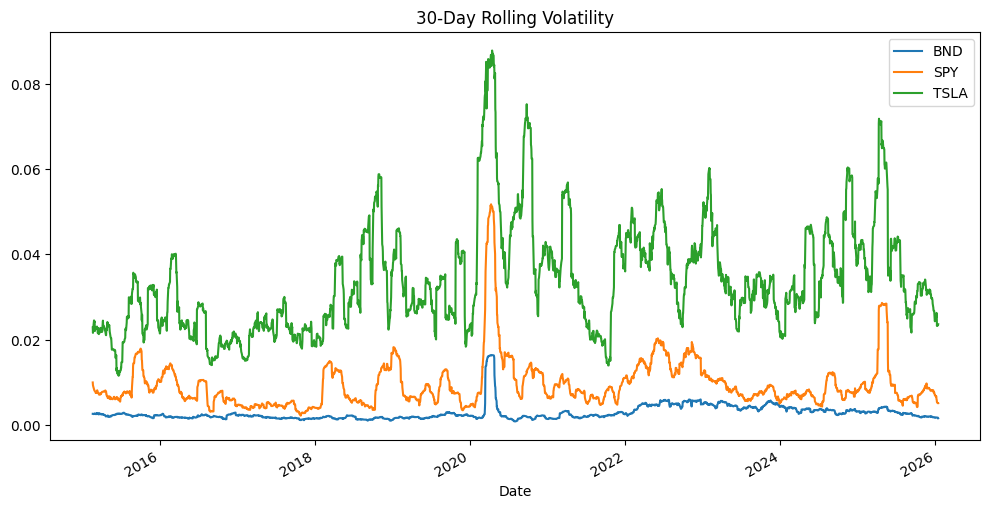

In [5]:
# 4. Visualize Volatility (Rolling Standard Deviation)
# TSLA is expected to be much more volatile than BND
rolling_vol = daily_returns.rolling(window=30).std()
rolling_vol.plot(figsize=(12, 6), title='30-Day Rolling Volatility')
plt.show()

In [6]:
# 5. Stationarity Test (ADF Test) for TSLA
# We test 'Close' (usually non-stationary) and 'Returns' (usually stationary)
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Result: Stationary (Good for ARIMA)")
    else:
        print("Result: Non-Stationary (Needs differencing)")
    print('-'*20)

adf_test(df['TSLA'], 'TSLA Price')
adf_test(daily_returns['TSLA'], 'TSLA Returns')

Augmented Dickey-Fuller Test: TSLA Price
ADF Statistic: -0.7801569882105672
p-value: 0.8248814297221101
Result: Non-Stationary (Needs differencing)
--------------------
Augmented Dickey-Fuller Test: TSLA Returns
ADF Statistic: -53.01961854424362
p-value: 0.0
Result: Stationary (Good for ARIMA)
--------------------


In [7]:
# 6. Save processed data for modeling
df.to_csv('../data/processed/cleaned_prices.csv')
daily_returns.to_csv('../data/processed/daily_returns.csv')